In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


# config pod wizualizacje
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [180]:
from scipy.stats import boxcox

data1 = pd.read_csv("data1_lab.csv")

# Zabezpieczenie: upewnij się, że wszystkie dane są dodatnie
data1 = data1.clip(lower=1e-9)

# Zastosowanie transformacji Boxa-Coxa do każdej kolumny
for col in data1.columns:
    data1[col], _ = boxcox(data1[col])

data1.describe()

,x1,x2,y
count,200.000,200.000,200.000
mean,2.489,2.996,10.580
std,1.797,2.109,4.073
min,-1.320,-1.182,-0.942
25%,1.089,1.414,8.390
50%,2.779,3.427,11.386
75%,4.135,4.707,13.565
max,5.188,6.180,18.756


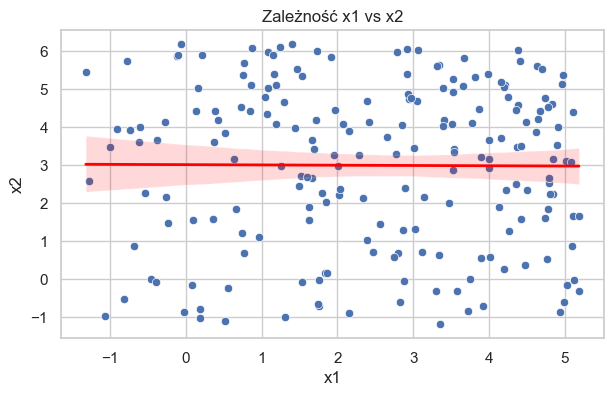

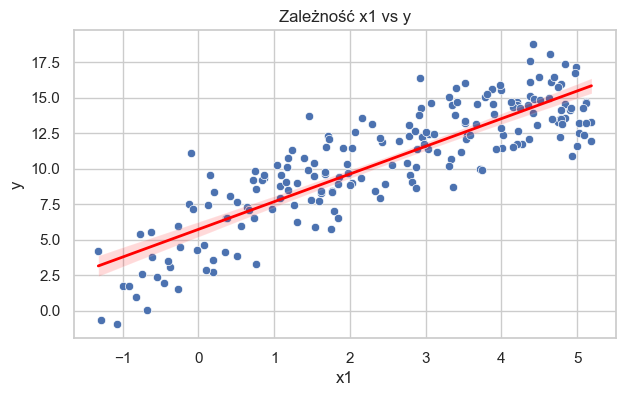

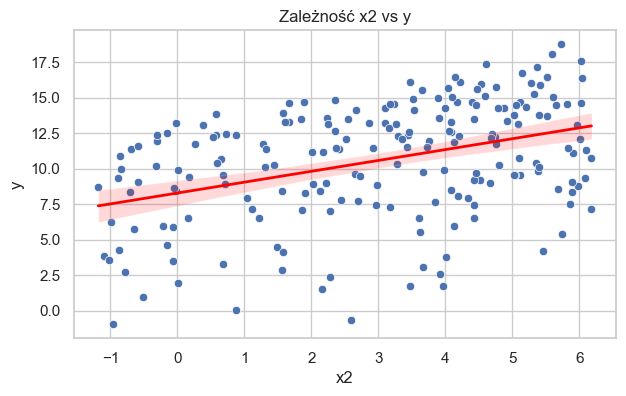

,x1,x2,y
x1,1.000,-0.006,0.859
x2,-0.006,1.000,0.396
y,0.859,0.396,1.000


In [181]:


# 1. Wykres x1 vs x2
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data1, x='x1', y='x2')

sns.regplot(data=data1, x='x1', y='x2', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność x1 vs x2')
plt.show()

# 2. Wykres x1 vs y
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data1, x='x1', y='y')
sns.regplot(data=data1, x='x1', y='y', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność x1 vs y')
plt.show()

# 3. Wykres x2 vs y
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data1, x='x2', y='y')
sns.regplot(data=data1, x='x2', y='y', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność x2 vs y')
plt.show()



correlation_matrix = data1.corr()
display(correlation_matrix)





In [182]:
X = data1[['x1', 'x2']]
y = data1['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# rozmiary
print(f'Rozmiar X_train : {X_train.shape}')
print(f'Rozmiar X_test  : {X_test.shape}')

Rozmiar X_train : (160, 2)
Rozmiar X_test  : (40, 2)


In [183]:
def preprocess_data(X_train, y_train):
    """
    Zwraca:
        X_train_scaled: przeszkalowane dane X_train
        y_train: oryginalne dane y_train
        scaler: nauczony (dopasowany) obiekt StandardScaler
        nie modyfikujmy y_train. afaik: to sie zostawia
    """

    """
    usunmy jeszcze outliera
    """
    # id_outliera = X_train['x1'].idxmax()
    # X_train_clean = X_train.drop(id_outliera)
    # y_train_clean = y_train.drop(id_outliera)
    # zrezygnowalem z tego bo nie wiedziec czemu minimalnie spadlo R2 XD (o 1 promil)

    scaler = StandardScaler()
    # obliczamy srednia i odchylenie. i przeskalowanie X_train
    X_train_scaled = scaler.fit_transform(X_train)
    return X_train_scaled, y_train, scaler

X_train_scaled, y_train_scaled, scaler = preprocess_data(X_train, y_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("Dane po standardyzacji (fragment):")
display(X_train_scaled_df.head())

print("\nStatystyki danych po standardyzacji (X_train_scaled_df)")
display(X_train_scaled_df.describe())


Dane po standardyzacji (fragment):


,x1,x2
0,-1.296,0.974
1,1.291,-0.138
2,0.727,0.538
3,0.047,-0.707
4,-0.427,0.582



Statystyki danych po standardyzacji (X_train_scaled_df)


,x1,x2
count,160.000,160.000
mean,-0.000,0.000
std,1.003,1.003
min,-2.120,-1.937
25%,-0.776,-0.805
50%,0.174,0.204
75%,0.926,0.849
max,1.510,1.511


In [184]:
# model 1 : dane surowe

model_raw = LinearRegression()

model_raw.fit(X_train, y_train)
print(f'W danych surowych wyraz wolny wynosi: {model_raw.intercept_}\n')
coef_df_raw = pd.DataFrame(model_raw.coef_, index=X_train.columns, columns=['Wspolczynnik (waga)'])
print("Wspolczynniki (a1, a2):")
display(coef_df_raw)


# model 2 : dane scaled

model_scaled = LinearRegression()

model_scaled.fit(X_train_scaled, y_train_scaled)
print(f'W danych scaled wyraz wolny wynosi: {model_scaled.intercept_}\n')
coef_df_scaled = pd.DataFrame(model_scaled.coef_, index=X_train.columns, columns=['Współczynnik (Waga)'])
print("Wspolczynniki (a1, a2):")
display(coef_df_scaled)


W danych surowych wyraz wolny wynosi: 3.3902939497628948

Wspolczynniki (a1, a2):


,Wspolczynnik (waga)
x1,1.940
x2,0.802


W danych scaled wyraz wolny wynosi: 10.564895891201013

Wspolczynniki (a1, a2):


,Współczynnik (Waga)
x1,3.475
x2,1.713


In [185]:
# przygotowanie danych X_test
# UZYWAYM TYLKO .transform() zamiast .fit_transform()

from numpy import mean


X_test_scaled = scaler.transform(X_test)

# predykcja oboma modelami
y_pred_raw = model_raw.predict(X_test)
y_pred_scaled = model_scaled.predict(X_test_scaled)

# surowe
mse_raw = mean_squared_error(y_test, y_pred_raw) # blad sredniokwadratowy
r2_raw = r2_score(y_test, y_pred_raw)            # im blizej 1.0 tym lepiej

# przeskalowane
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)      # wspolczynik determinacji

r2_raw_score = model_raw.score(X_test, y_test)   # just in case
r2_scaled_score = model_scaled.score(X_test_scaled, y_test)

print(f'R2 raw score : {r2_raw_score:.3f}')
print(f'R2 scaled score : {r2_scaled_score:.3f}')


evaluation_results = {
    'Model' : ['Raw', 'Scaled'],
    'MSE' : [mse_raw, mse_scaled],
    'R2'  : [r2_raw, r2_scaled]
}

evaluation_df = pd.DataFrame(evaluation_results)
print('Wyniki ewaluacji modeli')
display(evaluation_df)




R2 raw score : 0.859
R2 scaled score : 0.859
Wyniki ewaluacji modeli


,Model,MSE,R2
0,Raw,2.391,0.859
1,Scaled,2.391,0.859


In [186]:
# 2.2, 2.3

X_train_baseline = X_train[['x1']]
X_test_baseline = X_test[['x1']]

print(f'Ksztalt danych treningowych: {X_train_baseline.shape}')

model_baseline = LinearRegression()
model_baseline.fit(X_train_baseline, y_train)

print(f'W baseline modelu wyraz wolny wynosi: {model_baseline.intercept_}\n')
print(f'Wspolczynik (a1) dla x1 wynosi: {model_baseline.coef_[0]:.3f}')

y_pred_baseline = model_baseline.predict(X_test_baseline)

mse_baseline = mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f'MSE dla baseline : {mse_baseline:.3f}')
print(f'R2 dla baseline wynosi: {r2_baseline:.3f}')

Ksztalt danych treningowych: (160, 1)
W baseline modelu wyraz wolny wynosi: 5.7795818823320255

Wspolczynik (a1) dla x1 wynosi: 1.932
MSE dla baseline : 3.905
R2 dla baseline wynosi: 0.769


In [187]:
final_evaluation_results = {
    'Model': [
        'Bazowy (Baseline, y ~ x1)',
        'Liniowy (Surowe dane, y ~ x1 + x2)',
        'Liniowy (Przeskalowane dane, y ~ x1 + x2)'
    ],
    'MSE': [mse_baseline, mse_raw, mse_scaled],
    'R2': [r2_baseline, r2_raw, r2_scaled]
}

final_evaluation_df = pd.DataFrame(final_evaluation_results)
display(final_evaluation_df)

,Model,MSE,R2
0,"Bazowy (Baseline, y ~ x1)",3.905,0.769
1,"Liniowy (Surowe dane, y ~ x1 + x2)",2.391,0.859
2,"Liniowy (Przeskalowane dane, y ~ x1 + x2)",2.391,0.859


In [188]:
# ---------------------------------------------------------------

In [189]:
data_conc = pd.read_csv('Concrete_Data.csv')
data_conc.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000
mean,281.168,73.896,54.188,181.567,6.205,972.919,773.580,45.662,35.818
std,104.506,86.279,63.997,21.354,5.974,77.754,80.176,63.170,16.706
min,102.000,0.000,0.000,121.800,0.000,801.000,594.000,1.000,2.330
25%,192.375,0.000,0.000,164.900,0.000,932.000,730.950,7.000,23.710
50%,272.900,22.000,0.000,185.000,6.400,968.000,779.500,28.000,34.445
75%,350.000,142.950,118.300,192.000,10.200,1029.400,824.000,56.000,46.135
max,540.000,359.400,200.100,247.000,32.200,1145.000,992.600,365.000,82.600


In [190]:
#X_conc = data_conc[['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate',
#                   'fineaggregate', 'age']]
X_conc = data_conc[['cement', 'superplasticizer', 'age']]
y_conc = data_conc['csMPa']

correlation_matrix_conc = data_conc.corr()
display(correlation_matrix_conc)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
cement,1.000,-0.275,-0.397,-0.082,0.092,-0.109,-0.223,0.082,0.498
slag,-0.275,1.000,-0.324,0.107,0.043,-0.284,-0.282,-0.044,0.135
flyash,-0.397,-0.324,1.000,-0.257,0.378,-0.010,0.079,-0.154,-0.106
water,-0.082,0.107,-0.257,1.000,-0.658,-0.182,-0.451,0.278,-0.290
superplasticizer,0.092,0.043,0.378,-0.658,1.000,-0.266,0.223,-0.193,0.366
coarseaggregate,-0.109,-0.284,-0.010,-0.182,-0.266,1.000,-0.178,-0.003,-0.165
fineaggregate,-0.223,-0.282,0.079,-0.451,0.223,-0.178,1.000,-0.156,-0.167
age,0.082,-0.044,-0.154,0.278,-0.193,-0.003,-0.156,1.000,0.329
csMPa,0.498,0.135,-0.106,-0.290,0.366,-0.165,-0.167,0.329,1.000


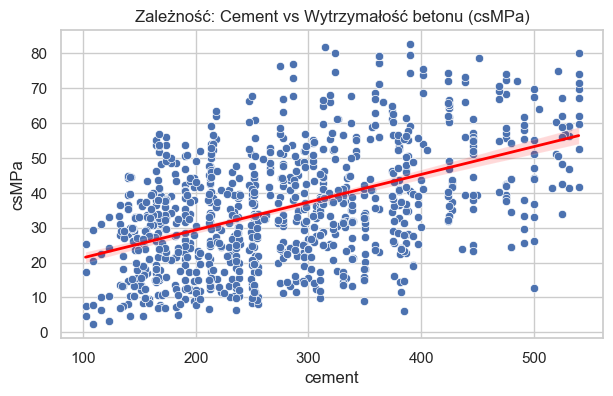

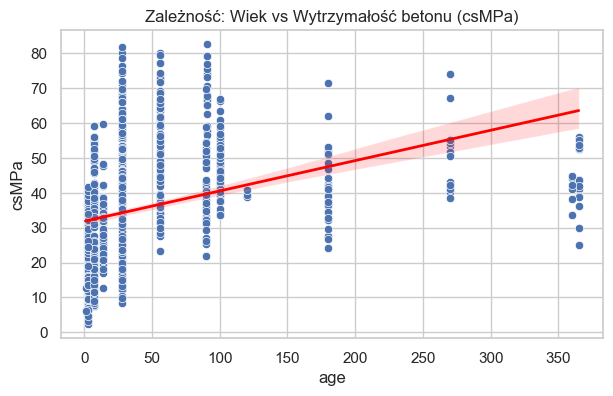

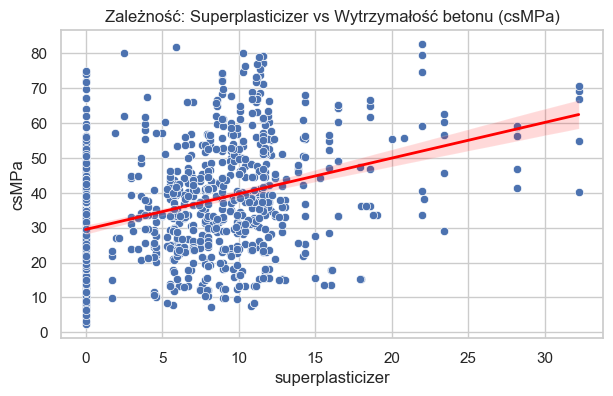

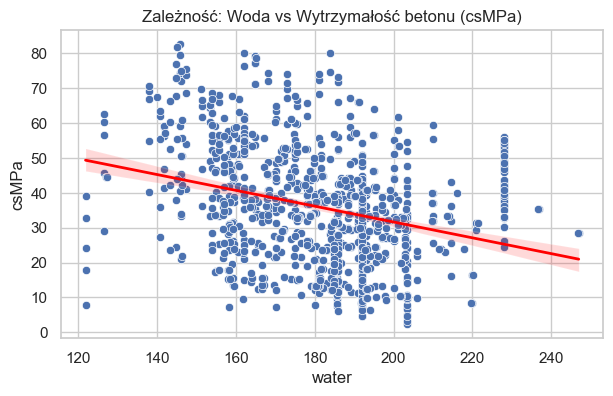

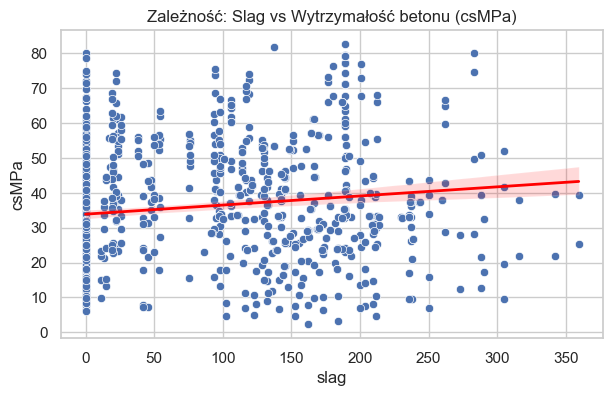

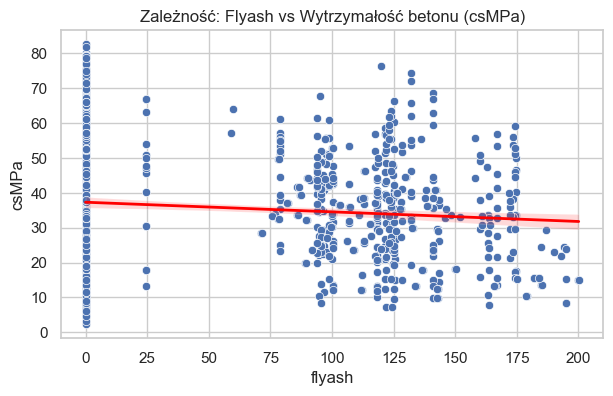

In [191]:
# 1. Cement vs csMPa
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data_conc, x='cement', y='csMPa')
sns.regplot(data=data_conc, x='cement', y='csMPa', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność: Cement vs Wytrzymałość betonu (csMPa)')
plt.show()

# 2. Wiek vs csMPa
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data_conc, x='age', y='csMPa')
sns.regplot(data=data_conc, x='age', y='csMPa', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność: Wiek vs Wytrzymałość betonu (csMPa)')
plt.show()

# 3. Superplasticizer vs csMPa
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data_conc, x='superplasticizer', y='csMPa')
sns.regplot(data=data_conc, x='superplasticizer', y='csMPa', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność: Superplasticizer vs Wytrzymałość betonu (csMPa)')
plt.show()

# 4. Woda vs csMPa
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data_conc, x='water', y='csMPa')
sns.regplot(data=data_conc, x='water', y='csMPa', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność: Woda vs Wytrzymałość betonu (csMPa)')
plt.show()

# 5. Slag vs csMPa
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data_conc, x='slag', y='csMPa')
sns.regplot(data=data_conc, x='slag', y='csMPa', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność: Slag vs Wytrzymałość betonu (csMPa)')
plt.show()

# 6. Flyash vs csMPa
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data_conc, x='flyash', y='csMPa')
sns.regplot(data=data_conc, x='flyash', y='csMPa', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Zależność: Flyash vs Wytrzymałość betonu (csMPa)')
plt.show()

In [192]:
X_conc = data_conc.drop('csMPa', axis = 1)
y_conc = data_conc['csMPa']

X_train_conc, X_test_conc, y_train_conc, y_test_conc = train_test_split(
    X_conc, y_conc, test_size=0.2, random_state=42
)

def preprocess_data(X_train, y_train):
    """
    Zwraca:
    - X_train_scaled : przeskalowane dane X_train
    - y_train: oryginalne dane y_train
    - scaler: nauczony, dopasowany obiekt
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    return X_train_scaled, y_train, scaler

In [193]:
# 3.2


# model 1 : surowe dane

model_conc_raw = LinearRegression()
model_conc_raw.fit(X_train_conc, y_train_conc) # trenowanie modelu
print(f'Wyraz wolny (b) : {model_conc_raw.intercept_:.3f}')
coef_df_conc_raw = pd.DataFrame(model_conc_raw.coef_, index=X_train_conc.columns, columns=['Wsołczynnik (Waga)'])
display(coef_df_conc_raw)




Wyraz wolny (b) : -28.824


,Wsołczynnik (Waga)
cement,0.119
slag,0.109
flyash,0.082
water,-0.135
superplasticizer,0.311
coarseaggregate,0.018
fineaggregate,0.024
age,0.116


In [194]:
X_train_conc_scaled, y_train_conc_scaled, scaler_conc = preprocess_data(X_train_conc, y_train_conc)
model_conc_scaled = LinearRegression()

model_conc_scaled.fit(X_train_conc_scaled, y_train_conc_scaled)
print(f"Wyraz wolny (b): {model_conc_scaled.intercept_:.3f}")
coef_df_adv_scaled = pd.DataFrame(model_conc_scaled.coef_, index=X_train_conc.columns, columns=['Wspolczynnik (Waga)'])

print(coef_df_adv_scaled)

Wyraz wolny (b): 35.858
                  Wspolczynnik (Waga)
cement                         12.788
slag                            9.434
flyash                          5.255
water                          -2.883
superplasticizer                1.852
coarseaggregate                 1.405
fineaggregate                   1.951
age                             7.037


In [195]:
# 3.3
from sklearn.metrics import mean_squared_error, r2_score


X_test_conc_scaled = scaler_conc.transform(X_test_conc)

y_pred_conc_raw = model_conc_raw.predict(X_test_conc)
y_pred_conc_scaled = model_conc_scaled.predict(X_test_conc_scaled)


# raw
mse_conc_raw = mean_squared_error(y_test_conc, y_pred_conc_raw)
r2_conc_raw = r2_score(y_test_conc, y_pred_conc_raw)

# scaled
mse_conc_scaled = mean_squared_error(y_test_conc, y_pred_conc_scaled)
r2_conc_scaled = r2_score(y_test_conc, y_pred_conc_scaled)

evaluation_results_conc = {
    'Model': ['Raw', 'Scaled'],
    'MSE': [mse_conc_raw, mse_conc_scaled],
    'R2': [r2_conc_raw, r2_conc_scaled]
}


evaluation_df_conc = pd.DataFrame(evaluation_results_conc)
display(evaluation_df_conc)

,Model,MSE,R2
0,Raw,95.971,0.628
1,Scaled,95.971,0.628


In [196]:
import numpy as np
from scipy import stats

residuals_conc_raw = y_test_conc - y_pred_conc_raw
residuals_conc_scaled = y_test_conc - y_pred_conc_scaled

# Test Shapiro-Wilka dla reszt z modelu na danych surowych
print("Test Shapiro-Wilka dla reszt modelu na surowych danych (zbiór Concrete):")
shapiro_test_raw = stats.shapiro(residuals_conc_raw)
print(shapiro_test_raw)
print(f"Statystyka testowa: {shapiro_test_raw.statistic:.4f}")
print(f"P-wartość: {shapiro_test_raw.pvalue:.4f}\n")

# Test Shapiro-Wilka dla reszt z modelu na danych przeskalowanych
print("Test Shapiro-Wilka dla reszt modelu na przeskalowanych danych (zbiór Concrete):")
shapiro_test_scaled = stats.shapiro(residuals_conc_scaled)
print(shapiro_test_scaled)
print(f"Statystyka testowa: {shapiro_test_scaled.statistic:.4f}")
print(f"P-wartość: {shapiro_test_scaled.pvalue:.4f}")


Test Shapiro-Wilka dla reszt modelu na surowych danych (zbiór Concrete):
ShapiroResult(statistic=np.float64(0.9867052680360355), pvalue=np.float64(0.05078116164380788))
Statystyka testowa: 0.9867
P-wartość: 0.0508

Test Shapiro-Wilka dla reszt modelu na przeskalowanych danych (zbiór Concrete):
ShapiroResult(statistic=np.float64(0.9867052680360346), pvalue=np.float64(0.0507811616437912))
Statystyka testowa: 0.9867
P-wartość: 0.0508
